# MRI k-space Data Augmentation Visualization

이 노트북에서는 `utils/data/augmentation.py`의 augmentation 함수들을 사용하여 k-space 데이터의 augmentation 결과를 시각적으로 확인할 수 있습니다.

---

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
from utils.data.augmentation import augment_kspace, visualize_augmentation
import random

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [2]:
in_dir = "../Data/train/kspace/brain_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace = kspace_f['kspace']
kspace = np.array(kspace)  # Convert to numpy array
print(f"kspace shape: {kspace.shape}")
print("kspace example:", kspace[0, 0, 0, 0])  # Example of a single k-space point

kspace = np.stack([kspace.real, kspace.imag], axis=-1)
print(f"kspace shape after stacking: {kspace.shape}")
kspace = torch.tensor(kspace, dtype=torch.float32)

kspace shape: (16, 16, 768, 396)
kspace example: (-4.305737e-06+1.0849908e-07j)
kspace shape after stacking: (16, 16, 768, 396, 2)


In [3]:
# Define augmentation configuration
augment_config = {
            'flip': random.choice([True, False]),
            'flip_horizontal': True,
            'translate': random.choice([True, False]),
            'translate_max': 2,
            'affine': True,
            'affine_rot': 5,
            'affine_scale': 0.05,
            'affine_shear': 0
        }
print("Augmentation config:", augment_config)

Augmentation config: {'flip': True, 'flip_horizontal': True, 'translate': False, 'translate_max': 2, 'affine': True, 'affine_rot': 5, 'affine_scale': 0.05, 'affine_shear': 0}


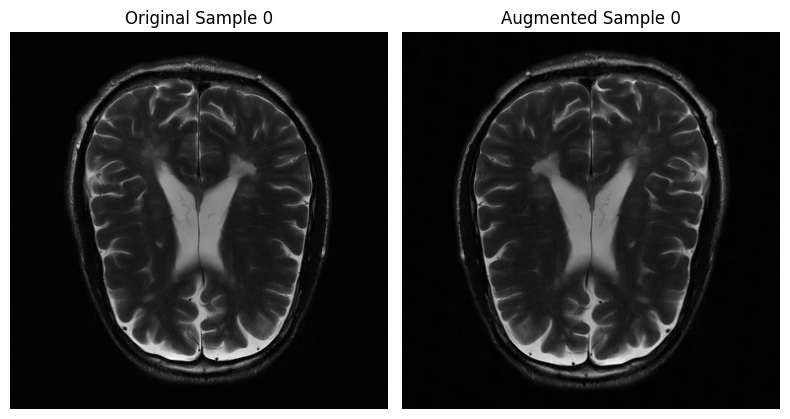

In [20]:
# Visualize original and augmented images
visualize_augmentation(kspace, augment_config)

In [ ]:
# Try different augmentation settings
augment_config2 = {
    'flip': True,
    'flip_horizontal': False,
    'rotate90': False,
    'translate': True,
    'translate_max': 4,
    'affine': True,
    'affine_rot': 2,
    'affine_scale': 0.02,
    'affine_shear': 1
}
print("Different augmentation config:", augment_config2)
visualize_augmentation(kspace, augment_config2, coil_idx=0)